# RIMES Preprocessing — Step by Step

Questo notebook esegue la pipeline di preprocessing RIMES **uno step alla volta**,
salvando e visualizzando il risultato intermedio ad ogni passaggio.

A differenza di IAM (un form intero -> un'immagine), RIMES parte da **singole righe di
testo** che vengono processate individualmente e poi **impilate verticalmente** in
batch da 5 righe per formare canvas 448x448 per ogni writer.

Pipeline:
1. Caricamento di alcune righe originali di uno stesso writer
2. Per ciascuna riga: binarizzazione Otsu
3. Per ciascuna riga: rimozione righe nere top/bottom
4. Per ciascuna riga: tight crop (proiezioni assiali, rho=0.018)
5. Split delle righe troppo larghe (>896px)
6. Calcolo dell'altezza minima del writer (clip [20,32])
7. Resize di ogni riga all'altezza comune, centratura in canvas 32x448 (max)
8. Batching: stack verticale di gruppi da 5 righe in canvas 448x448

Ad ogni step salviamo i PNG intermedi in `./steps_output_rimes/`.


## 0. Setup e configurazione

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# ==================== CONFIGURAZIONE ====================
RIMES_INPUT = "../datasets/RIMES/Handwritten2Text Training Dataset/Images"

# Writer da usare per la demo. Se None, viene scelto automaticamente il primo
# writer che ha almeno MIN_LINES_DEMO righe disponibili.
WRITER_ID = None
MIN_LINES_DEMO = 6   # quante righe di questo writer usare per la demo di batching

OUTPUT_DIR = "steps_output_rimes"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_SIZE = 448
LINE_HEIGHT = 32
LINES_PER_BATCH = TARGET_SIZE // LINE_HEIGHT - 9  # 448 // 32 - 9 = 5
MAX_WIDTH = TARGET_SIZE * 2  # 896, soglia di split

def show_and_save(img, title, filename, cmap="gray", figsize=(12, 4)):
    """Salva l'immagine intermedia su disco e la mostra inline"""
    out_path = os.path.join(OUTPUT_DIR, filename)
    cv2.imwrite(out_path, img)
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(f"{title}\nshape: {img.shape}  |  salvato in: {out_path}")
    plt.axis("off")
    plt.show()
    print(f"Salvato: {out_path}  |  shape: {img.shape}")


## 1. Scansione dataset e selezione di un writer

Raggruppiamo i file per writer (come nel notebook originale, parsing del nome file)
e selezioniamo un writer con abbastanza righe per mostrare bene il batching.


In [2]:
writer_images = defaultdict(list)

for img_name in sorted(os.listdir(RIMES_INPUT)):
    if not img_name.endswith((".jpg", ".png", ".jpeg")):
        continue
    parts = img_name.split("-")
    if len(parts) < 2:
        continue
    writer_id = parts[1].split("_")[0]
    writer_images[writer_id].append(os.path.join(RIMES_INPUT, img_name))

print(f"Trovati {len(writer_images)} writer totali")

if WRITER_ID is None:
    # sceglie il primo writer con abbastanza righe
    for wid, paths in writer_images.items():
        if len(paths) >= MIN_LINES_DEMO:
            WRITER_ID = wid
            break
    assert WRITER_ID is not None, "Nessun writer con abbastanza righe trovato, riduci MIN_LINES_DEMO"

demo_paths = sorted(writer_images[WRITER_ID])[:MIN_LINES_DEMO]
print(f"Writer selezionato per la demo: {WRITER_ID}  |  righe usate: {len(demo_paths)}")
for p in demo_paths:
    print("  -", os.path.basename(p))


Trovati 1500 writer totali
Writer selezionato per la demo: 0  |  righe usate: 6
  - eval2011-0_000001.jpg
  - eval2011-0_000002.jpg
  - eval2011-0_000003.jpg
  - eval2011-0_000004.jpg
  - eval2011-0_000005.jpg
  - eval2011-0_000006.jpg


## 2. Visualizza le righe originali

Prima di processarle, guardiamo come sono le righe grezze.


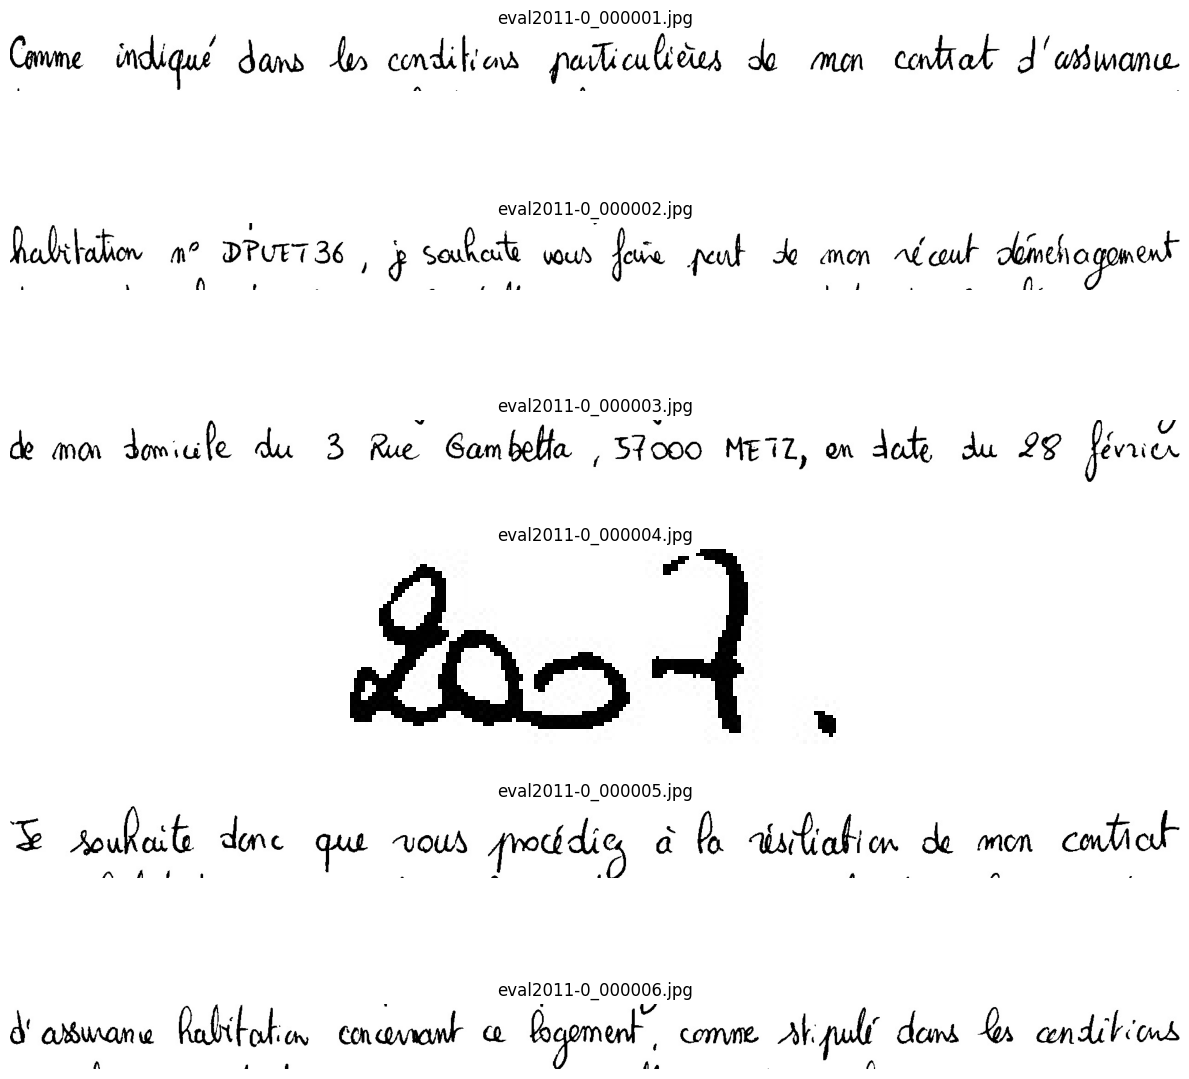

In [3]:
fig, axes = plt.subplots(len(demo_paths), 1, figsize=(12, 2 * len(demo_paths)))
if len(demo_paths) == 1:
    axes = [axes]
for ax, p in zip(axes, demo_paths):
    img = cv2.imread(p)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(p))
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_original_lines.png"), dpi=150, bbox_inches="tight")
plt.show()


## 3. Preprocessing di una singola riga (dettagliato passo-passo)

Prendiamo la **prima riga** del writer e mostriamo ogni singolo step nel dettaglio.
Le altre righe verranno poi processate con la stessa funzione, in modo compatto,
nella sezione successiva (per costruire il batch).


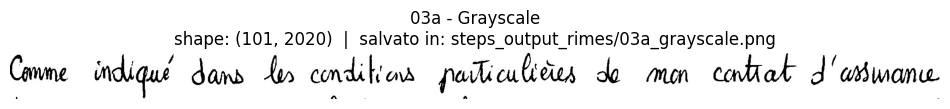

Salvato: steps_output_rimes/03a_grayscale.png  |  shape: (101, 2020)


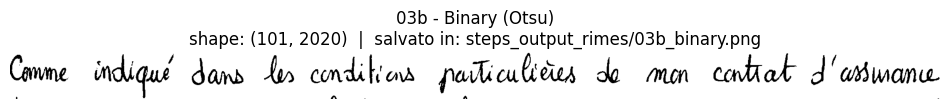

Salvato: steps_output_rimes/03b_binary.png  |  shape: (101, 2020)


In [4]:
def apply_threshold(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return gray, binary

demo_line_path = demo_paths[0]
image = cv2.imread(demo_line_path)

gray, binary = apply_threshold(image)

show_and_save(gray, "03a - Grayscale", "03a_grayscale.png")
show_and_save(binary, "03b - Binary (Otsu)", "03b_binary.png")


### 3.1 Rimozione righe nere top/bottom

first_row=0, last_row=101  (h originale=101)


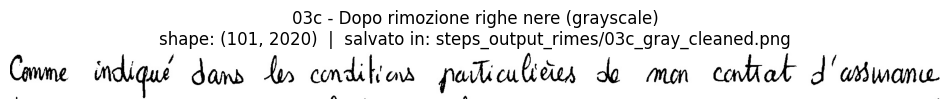

Salvato: steps_output_rimes/03c_gray_cleaned.png  |  shape: (101, 2020)


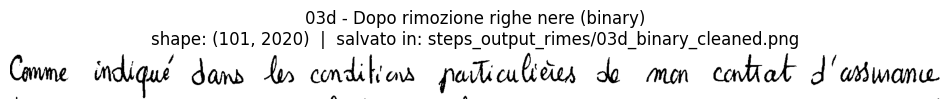

Salvato: steps_output_rimes/03d_binary_cleaned.png  |  shape: (101, 2020)


In [5]:
def compute_top_bottom_black_rows_crop(binary_image, black_ratio_threshold=0.5):
    h, w = binary_image.shape
    black_pixels_per_row = np.sum(binary_image == 0, axis=1)
    black_ratio = black_pixels_per_row / w
    valid_rows = np.where(black_ratio <= black_ratio_threshold)[0]
    if len(valid_rows) == 0:
        return 0, h
    return valid_rows[0], valid_rows[-1] + 1

first_row, last_row = compute_top_bottom_black_rows_crop(binary, black_ratio_threshold=0.5)
print(f"first_row={first_row}, last_row={last_row}  (h originale={binary.shape[0]})")

gray_cleaned = gray[first_row:last_row, :]
binary_cleaned = binary[first_row:last_row, :]

show_and_save(gray_cleaned, "03c - Dopo rimozione righe nere (grayscale)", "03c_gray_cleaned.png")
show_and_save(binary_cleaned, "03d - Dopo rimozione righe nere (binary)", "03d_binary_cleaned.png")


### 3.2 Tight crop (proiezioni assiali, rho=0.018)

[0] eval2011-0_000001.jpg: y1=5, y2=71, x1=0, x2=2008


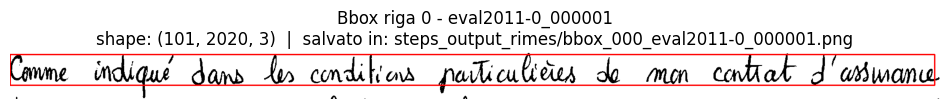

Salvato: steps_output_rimes/bbox_000_eval2011-0_000001.png  |  shape: (101, 2020, 3)
[1] eval2011-0_000002.jpg: y1=10, y2=126, x1=1, x2=2186


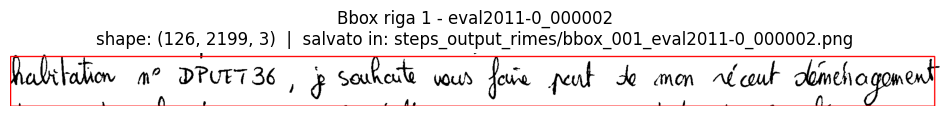

Salvato: steps_output_rimes/bbox_001_eval2011-0_000002.png  |  shape: (126, 2199, 3)
[2] eval2011-0_000003.jpg: y1=0, y2=74, x1=0, x2=2048


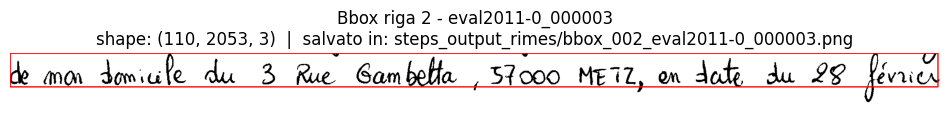

Salvato: steps_output_rimes/bbox_002_eval2011-0_000003.png  |  shape: (110, 2053, 3)
[3] eval2011-0_000004.jpg: y1=0, y2=50, x1=0, x2=111


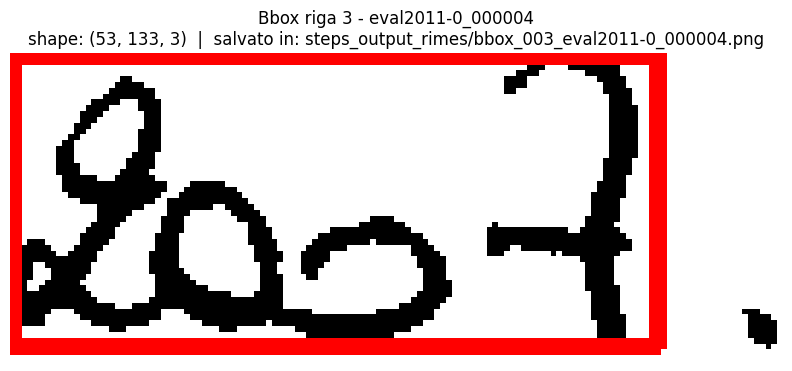

Salvato: steps_output_rimes/bbox_003_eval2011-0_000004.png  |  shape: (53, 133, 3)
[4] eval2011-0_000005.jpg: y1=12, y2=114, x1=8, x2=1832


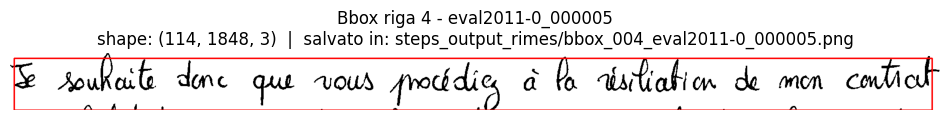

Salvato: steps_output_rimes/bbox_004_eval2011-0_000005.png  |  shape: (114, 1848, 3)
[5] eval2011-0_000006.jpg: y1=6, y2=113, x1=0, x2=2029


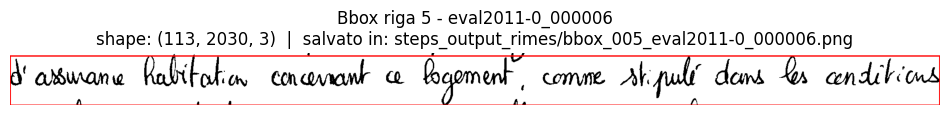

Salvato: steps_output_rimes/bbox_005_eval2011-0_000006.png  |  shape: (113, 2030, 3)

Salvati 6 bbox su 6 righe totali


In [12]:
bbox_results = []  # per tenere traccia di tutte le coordinate calcolate

for idx, p in enumerate(demo_paths):
    img = cv2.imread(p)
    if img is None:
        continue

    gray, binary = apply_threshold(img)
    first_row, last_row = compute_top_bottom_black_rows_crop(binary, black_ratio_threshold=0.5)
    gray_cleaned = gray[first_row:last_row, :]
    binary_cleaned = binary[first_row:last_row, :]

    crop_coords = compute_tight_crop_coords(binary_cleaned, padding=5)
    if crop_coords is None:
        print(f"[{idx}] {os.path.basename(p)}: nessun testo rilevato, skip")
        continue

    y1, y2, x1, x2 = crop_coords
    print(f"[{idx}] {os.path.basename(p)}: y1={y1}, y2={y2}, x1={x1}, x2={x2}")

    # Disegna il bbox
    vis = cv2.cvtColor(binary_cleaned.copy(), cv2.COLOR_GRAY2BGR)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)

    # Nome file univoco basato sul nome originale della riga
    stem = Path(p).stem
    fname = f"bbox_{idx:03d}_{stem}.png"
    show_and_save(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB), f"Bbox riga {idx} - {stem}", fname, cmap=None)

    bbox_results.append({
        "index": idx,
        "filename": os.path.basename(p),
        "y1": int(y1), "y2": int(y2), "x1": int(x1), "x2": int(x2),
    })

print(f"\nSalvati {len(bbox_results)} bbox su {len(demo_paths)} righe totali")

## 4. Preprocessing compatto di TUTTE le righe del writer

Ora applichiamo la stessa funzione (`preprocess_rimes_line`, che include anche
lo split delle righe troppo lunghe) a tutte le righe selezionate del writer,
per poter costruire il batch.


Totale righe (dopo eventuale split) pronte per il batch: 11


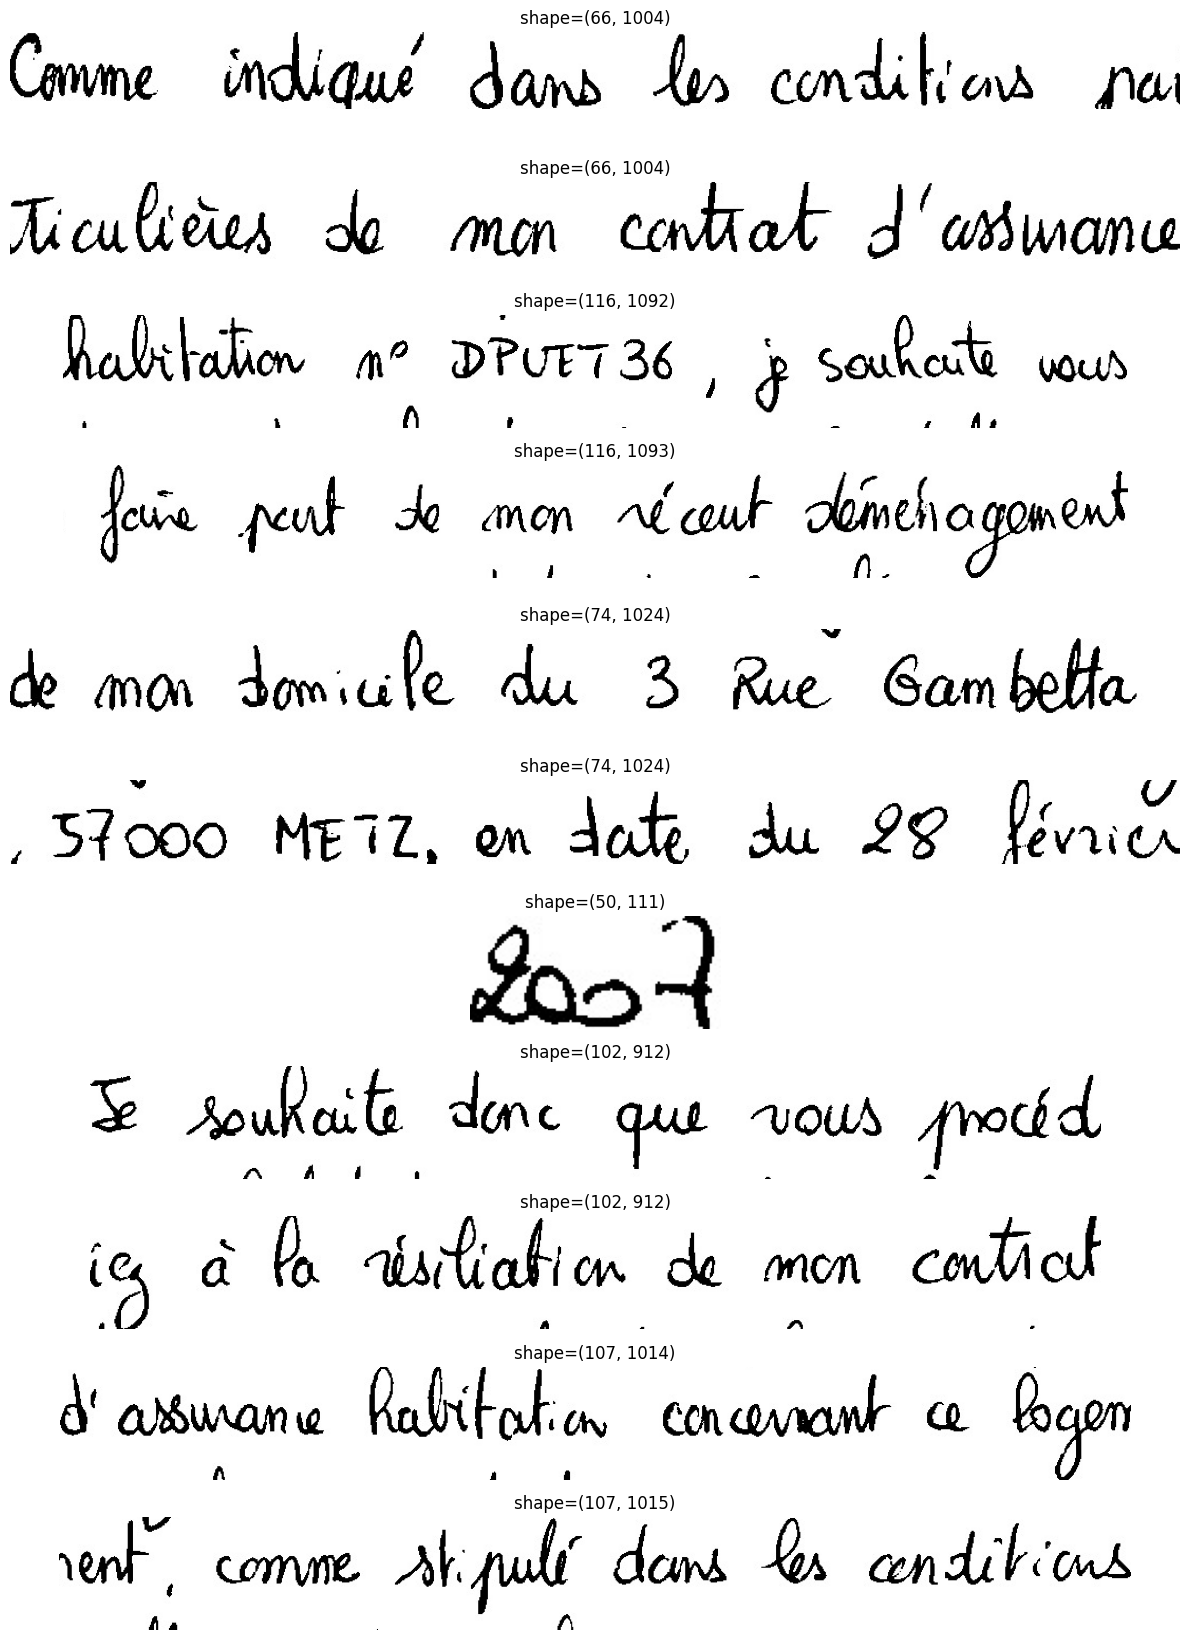

In [7]:
def preprocess_rimes_line(image, max_width=MAX_WIDTH):
    gray, binary = apply_threshold(image)

    first_row, last_row = compute_top_bottom_black_rows_crop(binary, black_ratio_threshold=0.5)
    gray_cleaned = gray[first_row:last_row, :]
    binary_cleaned = binary[first_row:last_row, :]

    crop_coords = compute_tight_crop_coords(binary_cleaned, padding=5)
    if crop_coords is None:
        return []

    y1, y2, x1, x2 = crop_coords
    gray_cropped = gray_cleaned[y1:y2, x1:x2]

    if gray_cropped.size == 0:
        return []

    if gray_cropped.shape[1] > max_width:
        mid = gray_cropped.shape[1] // 2
        return [gray_cropped[:, :mid], gray_cropped[:, mid:]]

    return [gray_cropped]

cropped_lines = []
for p in demo_paths:
    img = cv2.imread(p)
    if img is not None:
        line_splits = preprocess_rimes_line(img)
        cropped_lines.extend(line_splits)

print(f"Totale righe (dopo eventuale split) pronte per il batch: {len(cropped_lines)}")

fig, axes = plt.subplots(len(cropped_lines), 1, figsize=(12, 1.5 * len(cropped_lines)))
if len(cropped_lines) == 1:
    axes = [axes]
for ax, line in zip(axes, cropped_lines):
    ax.imshow(line, cmap="gray")
    ax.set_title(f"shape={line.shape}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_all_cropped_lines.png"), dpi=150, bbox_inches="tight")
plt.show()


## 5. Calcolo altezza minima del writer (clip [20, 32])

$$h_{\min} = \text{clip}\left(\min_l h_l,\ 20,\ 32\right)$$


In [8]:
min_height = min(line.shape[0] for line in cropped_lines)
print(f"Altezza minima grezza tra le righe: {min_height}")

min_height = max(min_height, 20)
min_height = min(min_height, LINE_HEIGHT)  # 32

print(f"h_min dopo clip [20,32]: {min_height}")


Altezza minima grezza tra le righe: 50
h_min dopo clip [20,32]: 32


## 6. Resize di ogni riga a h_min, centratura in canvas (h_min x 448)

Ogni riga viene ridimensionata mantenendo l'aspect ratio (larghezza massima 448),
poi centrata verticalmente (e allineata a sinistra orizzontalmente) in un canvas
bianco di dimensioni fisse `h_min x 448`.


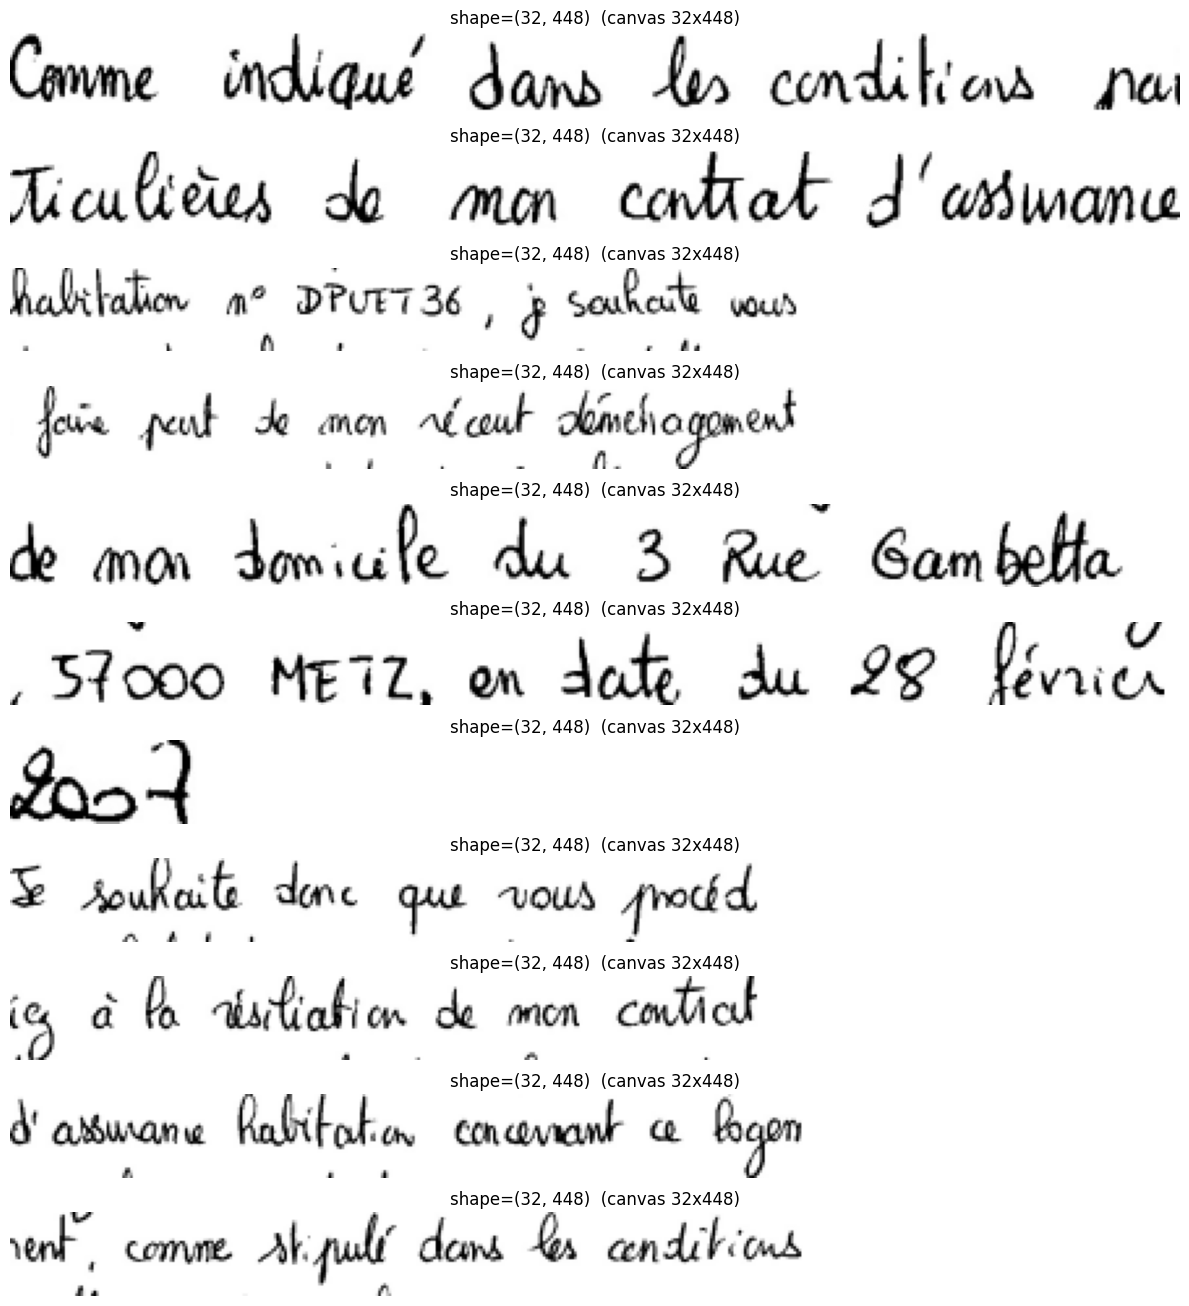

In [9]:
def resize_to_fixed_height(image, target_height, target_width):
    h, w = image.shape
    new_w = int(w * target_height / h)

    if new_w > target_width:
        new_w = target_width
        new_h = int(h * target_width / w)
    else:
        new_h = target_height

    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.full((target_height, target_width), 255, dtype=np.uint8)
    y_offset = (target_height - new_h) // 2
    canvas[y_offset:y_offset + new_h, :new_w] = resized

    return canvas

lines_normalized = []
for line in cropped_lines:
    resized_line = resize_to_fixed_height(line, min_height, TARGET_SIZE)
    lines_normalized.append(resized_line)

assert all(l.shape[0] == min_height for l in lines_normalized), "Altezze non uniformi!"

fig, axes = plt.subplots(len(lines_normalized), 1, figsize=(12, 1.2 * len(lines_normalized)))
if len(lines_normalized) == 1:
    axes = [axes]
for ax, line in zip(axes, lines_normalized):
    ax.imshow(line, cmap="gray")
    ax.set_title(f"shape={line.shape}  (canvas {min_height}x{TARGET_SIZE})")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_normalized_lines.png"), dpi=150, bbox_inches="tight")
plt.show()


## 7. Batching: stack verticale a gruppi di 5 righe

$$
N_{\text{batch}} = \lfloor 448/32 \rfloor - 9 = 5
$$

Le righe height-normalized vengono impilate verticalmente in gruppi da 5;
il canvas finale è sempre 448x448, con eventuale padding bianco se il writer
non ha abbastanza righe per riempire l'ultimo batch.


LINES_PER_BATCH = 5
Numero di batch prodotti per il writer 0: 3
Ogni batch occupa al massimo 160px di altezza su 448 disponibili (il resto e' padding bianco)


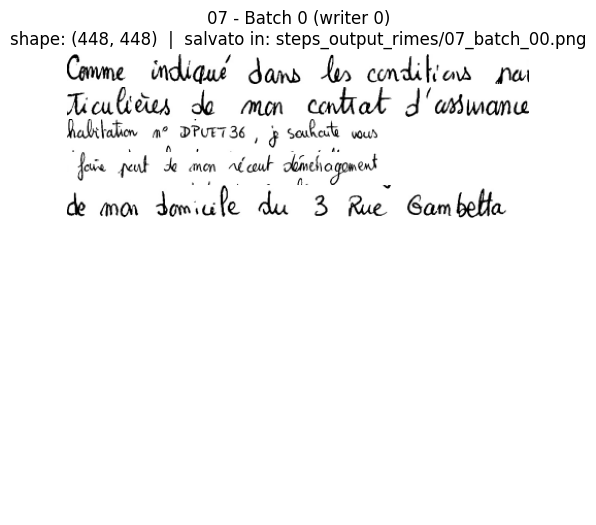

Salvato: steps_output_rimes/07_batch_00.png  |  shape: (448, 448)


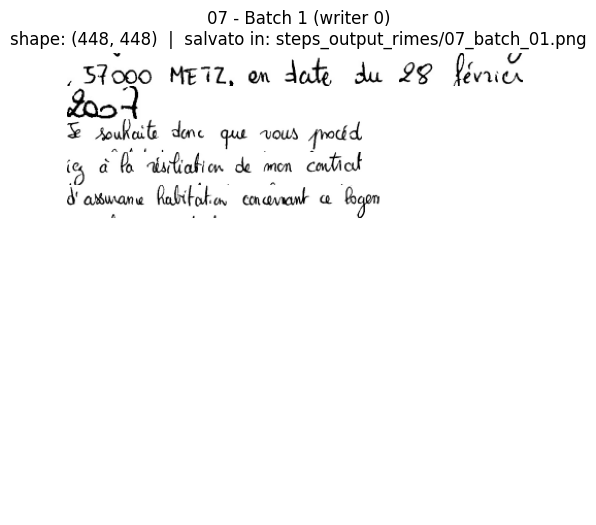

Salvato: steps_output_rimes/07_batch_01.png  |  shape: (448, 448)


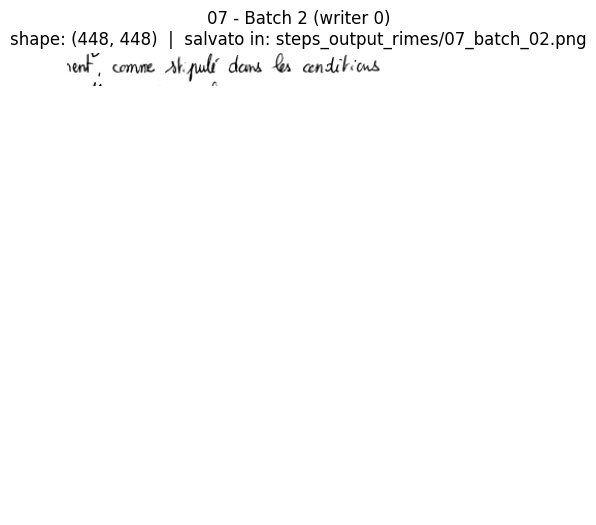

Salvato: steps_output_rimes/07_batch_02.png  |  shape: (448, 448)


In [10]:
print(f"LINES_PER_BATCH = {LINES_PER_BATCH}")

batches = []
for i in range(0, len(lines_normalized), LINES_PER_BATCH):
    batch_lines = lines_normalized[i:i + LINES_PER_BATCH]
    batch = np.vstack(batch_lines)

    canvas = np.full((TARGET_SIZE, TARGET_SIZE), 255, dtype=np.uint8)
    canvas[:batch.shape[0], :] = batch
    batches.append(canvas)

print(f"Numero di batch prodotti per il writer {WRITER_ID}: {len(batches)}")
print(f"Ogni batch occupa al massimo {LINES_PER_BATCH * min_height}px di altezza su 448 disponibili "
      f"(il resto e\' padding bianco)")

for idx, b in enumerate(batches):
    show_and_save(b, f"07 - Batch {idx} (writer {WRITER_ID})", f"07_batch_{idx:02d}.png", figsize=(6, 6))


## 8. Riepilogo visivo

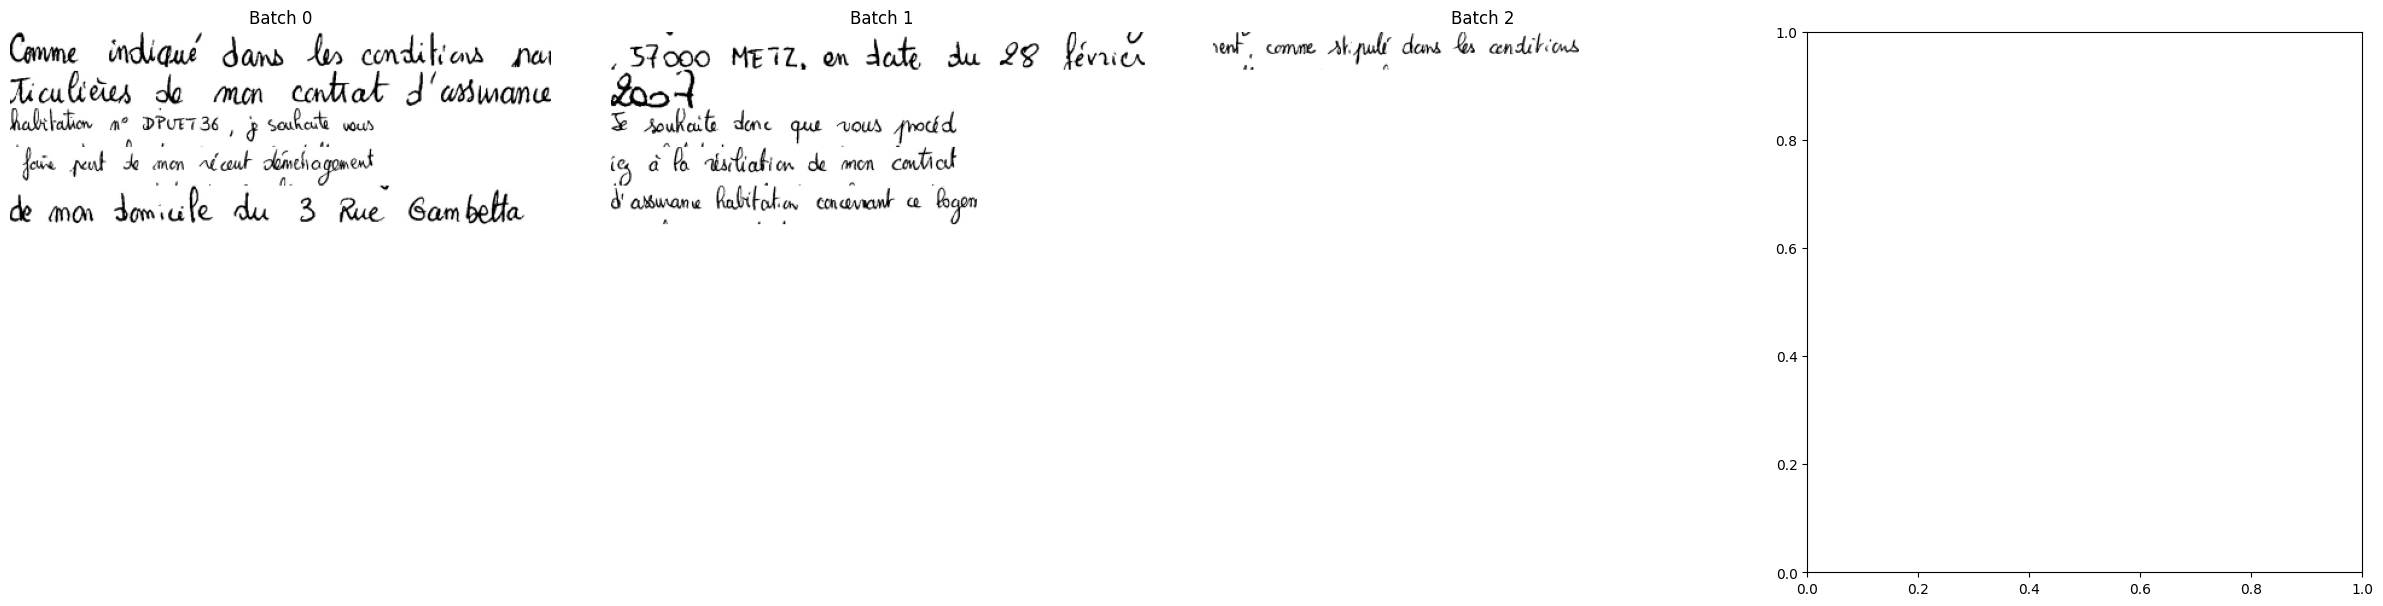


Pipeline completata. Tutti gli step intermedi sono in: steps_output_rimes/


In [11]:
fig, axes = plt.subplots(1, len(batches) + 1, figsize=(6 * (len(batches) + 1), 6))
if len(batches) == 0:
    axes = [axes]

orig_grid_path = os.path.join(OUTPUT_DIR, "01_original_lines.png")
if os.path.exists(orig_grid_path) and len(batches) >= 1:
    axes = np.atleast_1d(axes)

for idx, b in enumerate(batches):
    ax = axes[idx] if len(batches) > 1 else axes[0] if len(batches) == 1 else axes
    ax.imshow(b, cmap="gray")
    ax.set_title(f"Batch {idx}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "00_summary_batches.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPipeline completata. Tutti gli step intermedi sono in: {OUTPUT_DIR}/")
